 [자체 채점 결과]
 - Fold별 MAE: [0.13864978 0.15561508 0.15319099 0.16147303 0.15523047]
 - 평균 CV MAE : 0.152832
 [과적합 확인] 전체 Train MAE: 0.000003
 제출 파일 저장 완료: ../submissions/submit_22_svr_fulldata.csv


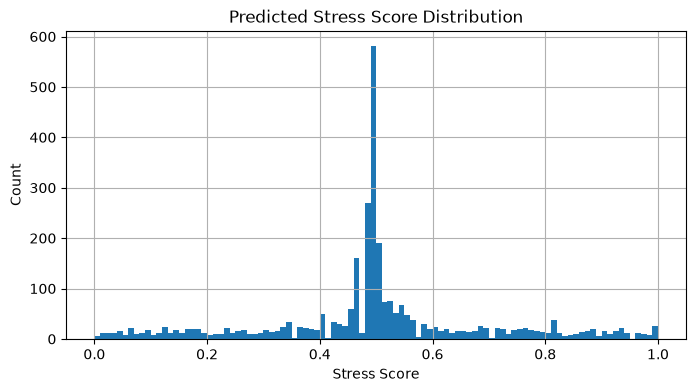

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR
from sklearn.preprocessing import QuantileTransformer, RobustScaler, OneHotEncoder
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
import warnings

warnings.filterwarnings('ignore')

# 1. 데이터 로드 (경로 확인 완료)
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

# 2. 전처리 함수 정의
# [대회 규정] test 에 get_dummies 를 적용하면 Data Leakage 에 해당한다.
#   - "테스트 데이터에 pandas.get_dummies() 함수를 적용하는 경우"
# train 에서만 fit 한 인코더로 test 를 transform 하는 방식으로 바꾼다.
# (Train 통계를 기반으로 test 를 전처리하는 것은 규정상 허용된다.)
OH_COLS = ['medical_history', 'family_medical_history', 'smoke_status']
OH_PREFIX = {'medical_history': 'mh', 'family_medical_history': 'fmh', 'smoke_status': 'smo'}
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

def preprocess_data(df, fit=False):
    temp = df.copy()
    
    # 결측치 처리
    temp['mean_working'] = temp['mean_working'].fillna(0)
    temp = temp.fillna('Unknown')
    
    # 순서형 데이터(Ordinal) 매핑
    d_gender = {"F" : 0, "M" : 1}
    d_activity = {"light" : 0, "moderate" : 1, "intense" : 2}
    d_smoke_status = {"non-smoker" : 0, "ex-smoker" : 1, "current-smoker" : 2}
    d_edu_level = {'high school diploma' : 1, 'bachelors degree' : 2, 'graduate degree' : 3, 'Unknown' : 0}
    d_sleep_pattern = {'sleep difficulty' : 0, 'normal' : 1, 'oversleeping' : 2}
    
    temp['gender'] = temp['gender'].map(d_gender)
    temp['activity'] = temp['activity'].map(d_activity)
    temp['smoke_status'] = temp['smoke_status'].map(d_smoke_status)
    temp['edu_level'] = temp['edu_level'].map(d_edu_level)
    temp['sleep_pattern'] = temp['sleep_pattern'].map(d_sleep_pattern)
    
    # 명목형 데이터 원-핫 인코딩 (인코더는 train 에서만 fit)
    if fit:
        ohe.fit(temp[OH_COLS])
    oh_cols = [f'{OH_PREFIX[c]}_{v}' for c, vals in zip(OH_COLS, ohe.categories_) for v in vals]
    oh = pd.DataFrame(ohe.transform(temp[OH_COLS]), columns=oh_cols, index=temp.index)
    
    temp = pd.concat([temp, oh], axis=1)
    
    # BMI 피처 추가
    temp['bmi'] = (temp['weight'] / ((temp['height'] / 100.0) ** 2)).round(2)
    
    # 불필요한 컬럼 삭제
    drop_cols = ["ID", 'medical_history', 'family_medical_history', 'smoke_status']
    temp = temp.drop(columns=drop_cols)
    
    return temp

# 전처리 실행
X_train_full = preprocess_data(train_df, fit=True)   # 인코더 fit 은 train 에서만
X_test = preprocess_data(test_df)                    # test 는 transform 만

X = X_train_full.drop(columns=['stress_score'])
y = X_train_full['stress_score']

# 3. 모델 파이프라인 설정
best_params = {'C': 3.963530707518144, 'gamma': 1.0631617004546035}

model_pipeline = make_pipeline(
    RobustScaler(),
    TransformedTargetRegressor(
        regressor=SVR(**best_params, kernel="rbf", epsilon=0.0),
        transformer=QuantileTransformer(output_distribution="normal", n_quantiles=min(1000, len(y)))
    )
)

# 4. [자체 채점] K-Fold 교차 검증을 통한 성능 평가
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')

print("="*40)
print(f" [자체 채점 결과]")
print(f" - Fold별 MAE: {-cv_scores}")
print(f" - 평균 CV MAE : {-cv_scores.mean():.6f}")
print("="*40)

# 5. 전체 데이터(100%) 학습 및 Train MAE 확인
model_pipeline.fit(X, y)
train_pred = model_pipeline.predict(X)
print(f" [과적합 확인] 전체 Train MAE: {mean_absolute_error(y, train_pred):.6f}")
print("="*40)

# 6. 테스트 데이터 추론 및 제출 파일 생성
test_pred = model_pipeline.predict(X_test)

submit = pd.read_csv('../data/sample_submission.csv')
submit["stress_score"] = test_pred

submit_filename = "submit_22_svr_fulldata.csv"
submit.to_csv(f"../submissions/{submit_filename}", index=False)
print(f" 제출 파일 저장 완료: ../submissions/{submit_filename}")

# 예측값 분포 시각화
plt.figure(figsize=(8, 4))
submit["stress_score"].hist(bins=100)
plt.title("Predicted Stress Score Distribution")
plt.xlabel("Stress Score")
plt.ylabel("Count")
plt.show()